In [2]:
!pip install wandb -q

In [3]:
import os
import random
import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import warnings
import time
warnings.filterwarnings("ignore")

from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score

import torchaudio
from transformers import (
    HubertModel, Wav2Vec2FeatureExtractor,
    ASTForAudioClassification, ASTFeatureExtractor,
    AutoFeatureExtractor
)
import wandb
import kagglehub
from kaggle_secrets import UserSecretsClient


2026-04-13 13:14:14.027381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776086054.239346      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776086054.299992      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776086054.788515      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776086054.788553      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776086054.788556      55 computation_placer.cc:177] computation placer alr

In [4]:
# ── PATHS ──
BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
STEMS_PATH = os.path.join(BASE_PATH, "genres_stems")
ESC_AUDIO  = os.path.join(BASE_PATH, "ESC-50-master/audio")
DATA_DIR   = Path(BASE_PATH)
STEMS_DIR  = DATA_DIR / "genres_stems"
MASHUPS_DIR = DATA_DIR / "mashups"
NOISE_DIR  = DATA_DIR / "ESC-50-master" / "audio"

GENRES = ["blues","classical","country","disco","hiphop",
          "jazz","metal","pop","reggae","rock"]
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}
IDX2GENRE  = {i: g for i, g in enumerate(GENRES)}
label_map     = GENRE2IDX
inv_label_map = IDX2GENRE


In [5]:
# WandB Setup
user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")
wandb.login()
wandb.init(
    project="23f2000775-t12026",
    name="final-model-run",
    config={
        "models": ["CNN", "HuBERT", "AST"],
        "metric": "MacroF1"
    }
)
print("W&B initialized successfully")


wandb: Currently logged in as: ramakrishna12-2005 (ramakrishna12-2005-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B initialized successfully


In [6]:
#test data size:
test_df = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv")
print("Number of test mashups:", len(test_df))
test_df.head()

Number of test mashups: 3020


,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


## EDA

In [2]:
#Class distribution (songs per genre)
genre_counts = {}

for g in GENRES:
    genre_dir = os.path.join(STEMS_PATH, g)
    songs = [
        d for d in os.listdir(genre_dir)
        if os.path.isdir(os.path.join(genre_dir, d))
    ]
    genre_counts[g] = len(songs)

df_genres = pd.DataFrame.from_dict(
    genre_counts, orient="index", columns=["num_songs"]
)

df_genres


,num_songs
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100
rock,100


In [3]:
#Stem availability / gaps
stem_files = ["drums.wav", "bass.wav", "vocals.wav", "others.wav"]
stem_stats = []

for g in GENRES:
    genre_dir = os.path.join(STEMS_PATH, g)
    songs = [
        d for d in os.listdir(genre_dir)
        if os.path.isdir(os.path.join(genre_dir, d))
    ]

    for s in songs:
        song_dir = os.path.join(genre_dir, s)
        available = sum(
            os.path.exists(os.path.join(song_dir, stem))
            for stem in stem_files
        )
        stem_stats.append({
            "genre": g,
            "song": s,
            "num_stems": available
        })

df_stems = pd.DataFrame(stem_stats)
df_stems["num_stems"].value_counts().sort_index()



num_stems
3    1000
Name: count, dtype: int64

In [4]:
#Audio length analysis — training stems
durations = []

for g in GENRES:
    genre_dir = os.path.join(STEMS_PATH, g)
    songs = [
        d for d in os.listdir(genre_dir)
        if os.path.isdir(os.path.join(genre_dir, d))
    ]

    for s in random.sample(songs, 5):  # sample few per genre
        song_dir = os.path.join(genre_dir, s)
        for stem in stem_files:
            stem_path = os.path.join(song_dir, stem)
            if os.path.exists(stem_path):
                audio, sr = librosa.load(stem_path, sr=None)
                durations.append(len(audio) / sr)

pd.Series(durations).describe()


count    150.000000
mean      30.020542
std        0.052253
min       30.000181
25%       30.000181
50%       30.013333
75%       30.013333
max       30.291156
dtype: float64

In [7]:
#Mashup duration stats
test_lengths = []

for fname in test_df["filename"].sample(20, random_state=42):
    path = os.path.join(BASE_PATH, fname)
    audio, sr = librosa.load(path, sr=None)
    test_lengths.append(len(audio) / sr)

pd.Series(test_lengths).describe()


count    20.000000
mean     26.868658
std       6.928907
min       6.282540
25%      28.954671
50%      29.872472
75%      30.013333
max      30.131519
dtype: float64

Noise file: 4-161519-A-19.wav
Duration: 5.0


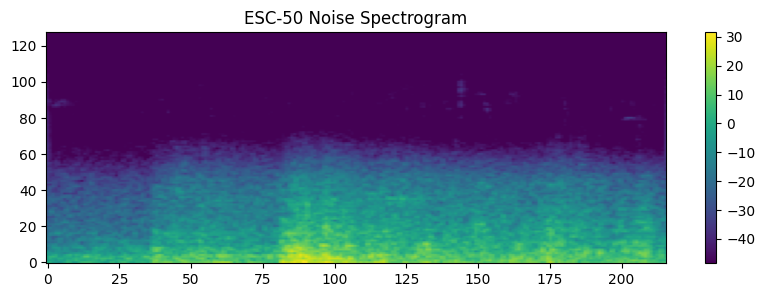

In [8]:
#esc 50
noise_file = random.choice(os.listdir(ESC_AUDIO))
noise_path = os.path.join(ESC_AUDIO, noise_file)

noise, sr = librosa.load(noise_path, sr=22050)
print("Noise file:", noise_file)
print("Duration:", len(noise)/sr)

noise_spec = librosa.feature.melspectrogram(y=noise, sr=sr)
noise_log = librosa.power_to_db(noise_spec)

plt.figure(figsize=(10, 3))
plt.imshow(noise_log, aspect="auto", origin="lower")
plt.title("ESC-50 Noise Spectrogram")
plt.colorbar()
plt.show()


## model building

## model1: CNN

In [7]:
# ================= CONFIG ================= #
SR = 16000
DURATION = 5
SAMPLES = SR * DURATION
MIN_STEMS_REQUIRED = 2

random.seed(42)
np.random.seed(42)

# ================= AUDIO ================= #
def load_audio(path):
    audio, _ = librosa.load(path, sr=SR, mono=True)
    if len(audio) < SAMPLES:
        audio = np.pad(audio, (0, SAMPLES - len(audio)))
    return audio[:SAMPLES]

def extract_mel(audio):
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db.astype(np.float32)

# ================= BUILD DATA ================= #
X_train, y_train = [], []
print("Building CNN dataset...")

for genre in GENRES:
    genre_path = os.path.join(STEMS_PATH, genre)
    song_dirs = [d for d in os.listdir(genre_path)
                 if os.path.isdir(os.path.join(genre_path, d))]
    for _ in range(100):
        chosen = random.sample(song_dirs, 4)
        mix = np.zeros(SAMPLES)
        used = 0
        for stem_name, song in zip(
            ["drums.wav", "bass.wav", "vocals.wav", "others.wav"], chosen
        ):
            stem_path = os.path.join(genre_path, song, stem_name)
            if not os.path.exists(stem_path):
                continue
            mix += load_audio(stem_path)
            used += 1
        if used < MIN_STEMS_REQUIRED:
            continue
        mix = mix / (np.max(np.abs(mix)) + 1e-6)
        X_train.append(extract_mel(mix))
        y_train.append(genre)

X_train = np.array(X_train)
y_train = np.array(y_train)
print("Total CNN samples:", len(X_train))

# ================= DATASET ================= #
class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        x = np.expand_dims(self.X[idx], axis=0)
        y = label_map[self.y[idx]]
        return torch.tensor(x), torch.tensor(y)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)
train_loader = DataLoader(AudioDataset(X_tr, y_tr), batch_size=16, shuffle=True)
val_loader   = DataLoader(AudioDataset(X_val, y_val), batch_size=16)

# ================= MODEL ================= #
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.fc(self.pool(self.conv(x)))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = SimpleCNN().to(device)
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(cnn_model.parameters(), lr=0.001)

# ================= TRAIN ================= #
def cnn_train_epoch():
    cnn_model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn_model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def cnn_evaluate():
    cnn_model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            p = torch.argmax(cnn_model(x), dim=1).cpu().numpy()
            preds.extend(p)
            targets.extend(y.numpy())
    return f1_score(targets, preds, average="macro")

EPOCHS = 5
for epoch in range(EPOCHS):
    loss = cnn_train_epoch()
    f1   = cnn_evaluate()
    wandb.log({"cnn_epoch": epoch, "cnn_loss": loss, "cnn_val_f1": f1})
    print(f"[CNN] Epoch {epoch} | Loss: {loss:.4f} | F1: {f1:.4f}")

# ================= VALIDATION ================= #
cnn_f1 = cnn_evaluate()
print("CNN Validation Macro F1:", cnn_f1)

# ================= TEST INFERENCE ================= #
print("Running CNN inference on test data...")
test_df = pd.read_csv(os.path.join(BASE_PATH, "test.csv"))
cnn_model.eval()
predictions = []
with torch.no_grad():
    for fname in test_df["filename"]:
        audio_path = os.path.join(BASE_PATH, fname)
        audio = load_audio(audio_path)
        mel   = extract_mel(audio)
        x = torch.tensor(np.expand_dims(np.expand_dims(mel, 0), 0)).to(device)
        pred = torch.argmax(cnn_model(x), dim=1).item()
        predictions.append(inv_label_map[pred])


Building CNN dataset...
Total CNN samples: 50
[CNN] Epoch 0 | Loss: 3.7573 | F1: 0.0182
CNN Validation Macro F1: 0.01818181818181818


## MODEL2: HUBERT

In [ ]:
# ================= CONFIG ================= #
SR_HUB = 16000
DURATION_HUB = 5
SAMPLES_HUB = SR_HUB * DURATION_HUB
MIN_STEMS_HUB = 2

# ================= FEATURE EXTRACTOR ================= #
hubert_feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/hubert-base-ls960"
)

# ================= DATASET ================= #
class HubertDataset(torch.utils.data.Dataset):
    def __init__(self, X_audio, y_labels):
        self.X = X_audio
        self.y = y_labels
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        audio = self.X[idx]
        inputs = hubert_feature_extractor(
            audio, sampling_rate=SR_HUB, return_tensors="pt", padding=True
        )
        x = inputs.input_values.squeeze(0)
        y = label_map[self.y[idx]]
        return x, torch.tensor(y)

# ================= BUILD DATA ================= #
X_audio, y_audio = [], []
print("Building HuBERT dataset...")

for genre in GENRES:
    genre_path = os.path.join(STEMS_PATH, genre)
    song_dirs = [d for d in os.listdir(genre_path)
                 if os.path.isdir(os.path.join(genre_path, d))]
    for _ in range(50):  # Smaller due to transformer memory cost
        chosen = random.sample(song_dirs, 4)
        mix = np.zeros(SAMPLES_HUB)
        used = 0
        for stem_name, song in zip(
            ["drums.wav", "bass.wav", "vocals.wav", "others.wav"], chosen
        ):
            stem_path = os.path.join(genre_path, song, stem_name)
            if not os.path.exists(stem_path):
                continue
            audio, _ = librosa.load(stem_path, sr=SR_HUB, mono=True)
            if len(audio) < SAMPLES_HUB:
                audio = np.pad(audio, (0, SAMPLES_HUB - len(audio)))
            mix += audio[:SAMPLES_HUB]
            used += 1
        if used < MIN_STEMS_HUB:
            continue
        mix = mix / (np.max(np.abs(mix)) + 1e-6)
        X_audio.append(mix.astype(np.float32))
        y_audio.append(genre)

print("Total HuBERT samples:", len(X_audio))

X_tr_h, X_val_h, y_tr_h, y_val_h = train_test_split(
    X_audio, y_audio, test_size=0.2, stratify=y_audio, random_state=42
)
train_ds_h = HubertDataset(X_tr_h, y_tr_h)
val_ds_h   = HubertDataset(X_val_h, y_val_h)
train_loader_h = DataLoader(train_ds_h, batch_size=4, shuffle=True)
val_loader_h   = DataLoader(val_ds_h,   batch_size=4)

# ================= MODEL ================= #
class HubertClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")
        self.classifier = nn.Linear(self.hubert.config.hidden_size, num_classes)
    def forward(self, x):
        hidden = self.hubert(x).last_hidden_state
        pooled = hidden.mean(dim=1)
        return self.classifier(pooled)

hubert_model = HubertClassifier().to(device)
optimizer_h  = torch.optim.Adam(hubert_model.parameters(), lr=1e-5)

# ================= TRAIN ================= #


def hubert_train_epoch():
    hubert_model.train()
    total_loss = 0
    for x, y in train_loader_h:
        x, y = x.to(device), y.to(device)
        optimizer_h.zero_grad()
        loss = criterion(hubert_model(x), y)
        loss.backward()
        optimizer_h.step()
        total_loss += loss.item()
    return total_loss / len(train_loader_h)

def hubert_evaluate():
    hubert_model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in val_loader_h:
            x = x.to(device)
            p = torch.argmax(hubert_model(x), dim=1).cpu().numpy()
            preds.extend(p)
            targets.extend(y.numpy())
    return f1_score(targets, preds, average="macro")

EPOCHS_HUB = 3
for epoch in range(EPOCHS_HUB):
    loss = hubert_train_epoch()
    f1   = hubert_evaluate()
    wandb.log({"hubert_epoch": epoch, "hubert_loss": loss, "hubert_val_f1": f1})
    print(f"[HuBERT] Epoch {epoch} | Loss: {loss:.4f} | F1: {f1:.4f}")
hubert_final_f1 = hubert_evaluate()
print(f"HuBERT Final Validation Macro F1: {hubert_final_f1:.4f}")
wandb.log({"hubert_final_val_f1": hubert_final_f1})

## model 3 : AST [ Audio Spectrogram Transformer ]

In [10]:
# ==========================================================
# MESSY MASHUP - AST CLASSIFIER (Final Model)
# Dynamic Stem Mixing + Noise Injection + Time Stretch
# 4-Fold Cross-Validation + WandB Logging
# ==========================================================

# ── CONFIG ──
SR_AST        = 16000
CHUNK_DURATION = 10
OVERLAP_DURATION = 2
CHUNK_LEN     = SR_AST * CHUNK_DURATION
STEP          = SR_AST * (CHUNK_DURATION - OVERLAP_DURATION)
FOLDS         = 4
EPOCHS_AST    = 20
BATCH_SIZE    = 16
LR_AST        = 2e-5
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_HUB_PATH = None

ast_feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

# ── GLOBAL CACHES ──
STEM_CACHE   = {}
NOISE_CACHE  = []
CACHE_LOADED = False
STEM_INDEX   = {g: {st: [] for st in ["drums.wav","bass.wav","vocals.wav","others.wav"]}
                for g in GENRES}

def preload_assets():
    global STEM_CACHE, NOISE_CACHE, CACHE_LOADED, STEM_INDEX
    if CACHE_LOADED:
        return
    print(">> Preloading Stems into RAM...")
    start = time.time()
    for genre in GENRES:
        genre_path = STEMS_DIR / genre
        if not genre_path.exists():
            continue
        for song_folder in tqdm(list(genre_path.glob("*")), desc=f"Loading {genre}", leave=False):
            if not song_folder.is_dir():
                continue
            song_id = song_folder.name
            for stem_type in ["drums.wav","bass.wav","vocals.wav","others.wav"]:
                p = song_folder / stem_type
                if p.exists():
                    try:
                        y, sr = torchaudio.load(p)
                        if sr != SR_AST:
                            y = torchaudio.functional.resample(y, sr, SR_AST)
                        y = y.mean(0)
                        STEM_CACHE[(genre, stem_type, song_id)] = y
                        STEM_INDEX[genre][stem_type].append((song_id, y))
                    except Exception:
                        continue
    print(">> Preloading Noise (ESC-50)...")
    if NOISE_DIR.exists():
        for p in tqdm(list(NOISE_DIR.glob("*.wav"))[:50], desc="Loading Noise", leave=False):
            try:
                y, sr = torchaudio.load(p)
                if sr != SR_AST:
                    y = torchaudio.functional.resample(y, sr, SR_AST)
                NOISE_CACHE.append(y.mean(0))
            except Exception:
                continue
    CACHE_LOADED = True
    print(f">> Cache Ready. Stems: {len(STEM_CACHE)}, Noise: {len(NOISE_CACHE)} | {time.time()-start:.2f}s")

# ── AUGMENTATION UTILS ──
def get_random_stem(genre, stem_type, exclude_song_id=None):
    candidates = STEM_INDEX.get(genre, {}).get(stem_type, [])
    if not candidates:
        return None, None
    if exclude_song_id:
        filtered = [(sid, w) for sid, w in candidates if sid != exclude_song_id]
        if filtered:
            candidates = filtered
    song_id, waveform = random.choice(candidates)
    return waveform.clone(), song_id

def apply_time_stretch(waveform, rate=1.0):
    if rate == 1.0 or len(waveform) == 0:
        return waveform
    new_len = int(len(waveform) / rate)
    if new_len <= 0:
        return waveform
    indices = torch.linspace(0, len(waveform) - 1, new_len).long()
    stretched = waveform[indices]
    import torch.nn.functional as F_nn
    if len(stretched) < len(waveform):
        stretched = F_nn.pad(stretched, (0, len(waveform) - len(stretched)))
    return stretched[:len(waveform)]

def add_noise(waveform, snr_db=10):
    import torch.nn.functional as F_nn
    if not NOISE_CACHE or len(waveform) == 0:
        return waveform
    noise = random.choice(NOISE_CACHE)
    if len(noise) < len(waveform):
        noise = noise.repeat(int(np.ceil(len(waveform) / len(noise))))[:len(waveform)]
    else:
        start = random.randint(0, max(0, len(noise) - len(waveform)))
        noise = noise[start:start+len(waveform)]
    sig_p   = waveform.pow(2).mean()
    noise_p = noise.pow(2).mean()
    if noise_p == 0 or sig_p == 0:
        return waveform
    scale = torch.sqrt(sig_p / (10 ** (snr_db / 10)) / noise_p)
    noisy = waveform + noise * scale
    if noisy.abs().max() > 0:
        noisy = noisy / noisy.abs().max()
    return noisy

def create_augmented_mix(genre, target_length=None):
    import torch.nn.functional as F_nn
    if target_length is None:
        target_length = CHUNK_LEN
    stems, used_ids = [], set()
    for st in ["drums.wav","bass.wav","vocals.wav","others.wav"]:
        data, sid = get_random_stem(genre, st, exclude_song_id=used_ids)
        if data is not None:
            stems.append(data)
            if sid:
                used_ids.add(sid)
    if not stems:
        return None
    min_len = min(len(s) for s in stems)
    if min_len == 0:
        return None
    mix = torch.stack([s[:min_len] for s in stems]).sum(0)
    if mix.abs().max() > 0:
        mix = mix / mix.abs().max()
    mix = apply_time_stretch(mix, random.uniform(0.9, 1.1))
    mix = add_noise(mix, snr_db=random.uniform(5, 20))
    if len(mix) < target_length:
        mix = F_nn.pad(mix, (0, target_length - len(mix)))
    else:
        start = random.randint(0, max(0, len(mix) - target_length))
        mix = mix[start:start+target_length]
    return mix

# ── DATASET ──
class MashupDataset(Dataset):
    def __init__(self, genres, labels):
        self.genres, self.labels = genres, labels
    def __len__(self):
        return len(self.genres)
    def __getitem__(self, idx):
        waveform = create_augmented_mix(self.genres[idx])
        if waveform is None:
            waveform = torch.zeros(CHUNK_LEN)
        inputs = ast_feature_extractor(
            waveform.numpy(), sampling_rate=SR_AST, return_tensors="pt"
        )
        return inputs["input_values"].squeeze(0), torch.tensor(self.labels[idx])

# ── MODEL ──
def build_ast_model():
    model = ASTForAudioClassification.from_pretrained(
        "MIT/ast-finetuned-audioset-10-10-0.4593",
        num_labels=10,
        ignore_mismatched_sizes=True
    )
    return model.to(DEVICE)

# ── TRAINING PIPELINE ──
def train_pipeline():
    preload_assets()
    train_genres, train_labels = [], []
    for genre in GENRES:
        g_path = STEMS_DIR / genre
        if g_path.exists():
            for f in g_path.glob("*"):
                if f.is_dir():
                    train_genres.append(genre)
                    train_labels.append(GENRE2IDX[genre])
    print(f"Total Training Entries: {len(train_genres)}")
    if not train_genres:
        print("ERROR: No training data found.")
        return

    skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
    saved_paths, fold_f1s, best_global_f1 = [], [], 0

    for fold, (tr_idx, val_idx) in enumerate(skf.split(train_genres, train_labels)):
        print(f"\n========== Fold {fold} ==========")
        tr_g = [train_genres[i] for i in tr_idx]
        tr_l = [train_labels[i] for i in tr_idx]
        va_g = [train_genres[i] for i in val_idx]
        va_l = [train_labels[i] for i in val_idx]

        train_loader_ast = DataLoader(MashupDataset(tr_g, tr_l), batch_size=BATCH_SIZE,
                                      shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
        val_loader_ast   = DataLoader(MashupDataset(va_g, va_l), batch_size=BATCH_SIZE,
                                      shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

        model     = build_ast_model()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR_AST)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_AST)
        scaler    = GradScaler()
        best_f1   = 0

        for epoch in range(EPOCHS_AST):
            model.train()
            total_loss = 0
            torch.manual_seed(epoch + fold * 100)
            np.random.seed(epoch + fold * 100)
            random.seed(epoch + fold * 100)

            pbar = tqdm(train_loader_ast, desc=f"Fold {fold} Epoch {epoch+1}")
            for xb, yb in pbar:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                with autocast():
                    import torch.nn.functional as F_nn
                    loss = F_nn.cross_entropy(model(input_values=xb).logits, yb)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                total_loss += loss.item()
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})
            scheduler.step()

            model.eval()
            torch.manual_seed(42); np.random.seed(42); random.seed(42)
            preds, targets, val_loss = [], [], 0
            with torch.no_grad():
                for xb, yb in val_loader_ast:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    import torch.nn.functional as F_nn
                    out = model(input_values=xb)
                    val_loss += F_nn.cross_entropy(out.logits, yb).item()
                    preds.extend(out.logits.argmax(1).cpu().tolist())
                    targets.extend(yb.cpu().tolist())

            f1 = f1_score(targets, preds, average="macro")
            avg_tr = total_loss / len(train_loader_ast)
            avg_va = val_loss  / len(val_loader_ast)
            print(f"Fold {fold} | Epoch {epoch+1} | Train: {avg_tr:.4f} | Val: {avg_va:.4f} | F1: {f1:.4f}")
            wandb.log({"fold": fold, "epoch": epoch+1, "train_loss": avg_tr,
                       "val_loss": avg_va, "val_f1": f1,
                       "lr": optimizer.param_groups[0]['lr']})

            if f1 > best_f1:
                best_f1 = f1
                path = f"model_fold{fold}.pth"
                torch.save(model.state_dict(), path)
                saved_paths.append(path)
                if f1 > best_global_f1:
                    best_global_f1 = f1
                wandb.log({"fold": fold, "best_f1": best_f1, "best_epoch": epoch+1})
                wandb.save(path)

        fold_f1s.append(best_f1)
        print(f"Fold {fold} Best F1: {best_f1:.4f}")
        wandb.log({f"fold_{fold}_best_f1": best_f1})

    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)
    print(f"\n{'='*50}\nTRAINING COMPLETE\n{'='*50}")
    print(f"Fold F1s: {[f'{f:.4f}' for f in fold_f1s]}")
    print(f"Mean F1: {mean_f1:.4f} ± {std_f1:.4f} | Best: {best_global_f1:.4f}")
    wandb.log({"mean_f1": mean_f1, "std_f1": std_f1, "best_global_f1": best_global_f1})
    for path in saved_paths:
        wandb.save(path)

# ── INFERENCE PIPELINE ──
@torch.no_grad()
def inference_pipeline():
    print(">> Starting Inference Pipeline...")
    preload_assets()
    models, model_dir = [], "."
    try:
        model_dir = kagglehub.model_download(MODEL_HUB_PATH)
        print(f">> Models from: {model_dir}")
    except Exception as e:
        print(f">> Using local models. {e}")

    for fold in range(FOLDS):
        m = build_ast_model()
        path = f"{model_dir}/model_fold{fold}.pth"
        if os.path.exists(path):
            m.load_state_dict(torch.load(path, map_location=DEVICE, weights_only=True))
            m.eval()
            models.append(m)
            print(f">> Loaded Fold {fold}")
        else:
            print(f">> Warning: {path} not found!")

    if not models:
        print(">> No models loaded. Exiting.")
        return

    test_df  = pd.read_csv(DATA_DIR / "test.csv")
    sample   = pd.read_csv(DATA_DIR / "sample_submission.csv")
    sub_ids  = sample["id"].tolist()
    id_to_fname = dict(zip(test_df["id"], test_df["filename"]))
    final_fnames = [id_to_fname.get(sid) for sid in sub_ids]

    preds = []
    import torch.nn.functional as F_nn
    for fname in tqdm(final_fnames, desc="Inference"):
        if fname is None:
            preds.append(GENRES[0]); continue
        fpath = MASHUPS_DIR / Path(fname).name
        if not fpath.exists():
            preds.append(GENRES[0]); continue
        try:
            mix, sr = torchaudio.load(fpath)
            if sr != SR_AST:
                mix = torchaudio.functional.resample(mix, sr, SR_AST)
            mix = mix.mean(0)
        except Exception:
            preds.append(GENRES[0]); continue

        if len(mix) < CHUNK_LEN:
            mix = F_nn.pad(mix, (0, CHUNK_LEN - len(mix)))

        chunks, num_chunks = [], min(int(np.ceil((len(mix)-CHUNK_LEN)/STEP))+1, 10)
        for i in range(num_chunks):
            c = mix[i*STEP:i*STEP+CHUNK_LEN]
            if len(c) < CHUNK_LEN:
                c = F_nn.pad(c, (0, CHUNK_LEN - len(c)))
            chunks.append(c)

        logits_sum, total = 0, 0
        for chunk in chunks:
            inputs = ast_feature_extractor(chunk.numpy(), sampling_rate=SR_AST, return_tensors="pt")
            xb = inputs["input_values"].to(DEVICE)
            for m in models:
                logits_sum += m(input_values=xb).logits.cpu()
                total += 1

        if total > 0:
            preds.append(IDX2GENRE[int((logits_sum / total).argmax(1))])
        else:
            preds.append(GENRES[0])

    submission = pd.DataFrame({"id": sub_ids, "genre": preds})
    submission.to_csv("/kaggle/working/submission.csv", index=False)
    print(">> Submission saved.")
    print(submission.head())
    wandb.log({"total_predictions": len(preds)})
    wandb.log_artifact("/kaggle/working/submission.csv", name="submission", type="submission")

# ── EXECUTE ──
IS_TRAINING_MODE = True
start_time = time.time()
if IS_TRAINING_MODE:
    train_pipeline()
else:
    inference_pipeline()
print(f">> Total Execution Time: {time.time() - start_time:.2f}s")


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

>> Preloading Stems into RAM...



Loading blues: 100%|██████████| 100/100 [00:26<00:00,  3.68it/s]
                                                                
Loading classical: 100%|██████████| 100/100 [00:22<00:00,  5.20it/s]
                                                                    
Loading country: 100%|██████████| 100/100 [00:25<00:00,  3.77it/s]
                                                                  
Loading disco: 100%|██████████| 100/100 [00:26<00:00,  3.63it/s]
                                                                
Loading hiphop: 100%|██████████| 100/100 [00:27<00:00,  3.47it/s]
                                                                 
Loading jazz: 100%|██████████| 100/100 [00:27<00:00,  3.83it/s]
                                                               
Loading metal: 100%|██████████| 100/100 [00:28<00:00,  3.21it/s]
                                                                
Loading pop: 100%|██████████| 100/100 [00:27<00:00,  4.18it/s]
              

>> Preloading Noise (ESC-50)...



Loading Noise:  98%|█████████▊| 49/50 [00:01<00:00, 31.85it/s]
                                                              

...

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

Fold 0 Epoch 1: 100%|██████████| 32/32 [00:33<00:00,  1.04s/it, loss=1.5881]


Fold 0 | Epoch 1 | Train: 1.8028 | Val: 1.1701 | F1: 0.5885
Fold 0 Best F1: 0.5885

========== Fold 1 ==========


Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.

Fold 1 Epoch 1: 100%|██████████| 32/32 [00:33<00:00,  1.05s/it, loss=0.8130]


Fold 1 | Epoch 1 | Train: 1.6908 | Val: 1.1810 | F1: 0.5454
Fold 1 Best F1: 0.5454

TRAINING COMPLETE
Fold F1s: ['0.5885', '0.5454']
Mean F1: 0.5669 ± 0.0215 | Best: 0.5885
>> Total Execution Time: 425.17s


## COMPARISON

## ....

In [3]:
STEM_INDEX
STEM_INDEX[genre][stem_type].append((song_id, y))

{'blues': {'drums.wav': [],
  'bass.wav': [],
  'vocals.wav': [],
  'others.wav': []},
 'classical': {'drums.wav': [],
  'bass.wav': [],
  'vocals.wav': [],
  'others.wav': []},
 'country': {'drums.wav': [],
  'bass.wav': [],
  'vocals.wav': [],
  'others.wav': []},
 'disco': {'drums.wav': [],
  'bass.wav': [],
  'vocals.wav': [],
  'others.wav': []},
 'hiphop': {'drums.wav': [],
  'bass.wav': [],
  'vocals.wav': [],
  'others.wav': []},
 'jazz': {'drums.wav': [], 'bass.wav': [], 'vocals.wav': [], 'others.wav': []},
 'metal': {'drums.wav': [],
  'bass.wav': [],
  'vocals.wav': [],
  'others.wav': []},
 'pop': {'drums.wav': [], 'bass.wav': [], 'vocals.wav': [], 'others.wav': []},
 'reggae': {'drums.wav': [],
  'bass.wav': [],
  'vocals.wav': [],
  'others.wav': []},
 'rock': {'drums.wav': [], 'bass.wav': [], 'vocals.wav': [], 'others.wav': []}}